In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

In [2]:
df=pd.read_csv('diabetes.csv')

In [3]:

columns = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']
df=df.drop(columns="SkinThickness")



In [4]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'Insulin', 'BMI',
       'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [5]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [6]:
smote = SMOTE(random_state=42)
X_bal, y_bal = smote.fit_resample(X, y)
print("Before SMOTE:", y.value_counts().to_dict())
print("After SMOTE:", y_bal.value_counts().to_dict())

Before SMOTE: {0: 500, 1: 268}
After SMOTE: {1: 500, 0: 500}


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal)


In [8]:

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
rf = RandomForestClassifier(random_state=42)
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
gb = GradientBoostingClassifier(random_state=42)

In [10]:
ensemble = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb), ('gb', gb)],
    voting='soft'  # use probabilities instead of hard labels
)

In [11]:
param_grid = {
    'xgb__n_estimators': [100, 200],
    'xgb__max_depth': [3, 5],
    'xgb__learning_rate': [0.01, 0.1],
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [5, 10]
}


In [12]:
pipeline = Pipeline(steps=[
    ('model', ensemble)
])


In [13]:
ensemble.fit(X_train, y_train)

,estimators,"[('rf', ...), ('xgb', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1


In [14]:
y_pred = ensemble.predict(X_test)
y_proba = ensemble.predict_proba(X_test)[:, 1]

In [15]:
print("Ensemble Model Results")
print("Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print("AUC Score:", round(roc_auc_score(y_test, y_proba), 4))
print("Classification Report:", classification_report(y_test, y_pred))

Ensemble Model Results
Accuracy: 83.0 %
AUC Score: 0.9069
Classification Report:               precision    recall  f1-score   support

           0       0.85      0.80      0.82       100
           1       0.81      0.86      0.83       100

    accuracy                           0.83       200
   macro avg       0.83      0.83      0.83       200
weighted avg       0.83      0.83      0.83       200



In [16]:
import joblib
joblib.dump(ensemble, "diabates.pkl")


['diabates.pkl']

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
df=pd.read_csv('diabetes.csv')
columns = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']
df=df.drop(columns="SkinThickness")
df.columns
X = df.drop('Outcome', axis=1)
y = df['Outcome']
smote = SMOTE(random_state=42)
X_bal, y_bal = smote.fit_resample(X, y)
print("Before SMOTE:", y.value_counts().to_dict())
print("After SMOTE:", y_bal.value_counts().to_dict())
X_train, X_test, y_train, y_test = train_test_split(X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
rf = RandomForestClassifier(random_state=42)
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
gb = GradientBoostingClassifier(random_state=42)
ensemble = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb), ('gb', gb)],
    voting='soft'  # use probabilities instead of hard labels
    
)
param_grid = {
    'xgb__n_estimators': [100, 200],
    'xgb__max_depth': [3, 5],
    'xgb__learning_rate': [0.01, 0.1],
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [5, 10]
}
pipeline = Pipeline(steps=[
    ('model', ensemble)
])
ensemble.fit(X_train, y_train)
y_pred = ensemble.predict(X_test)
y_proba = ensemble.predict_proba(X_test)[:, 1]
print("Ensemble Model Results")
print("Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print("AUC Score:", round(roc_auc_score(y_test, y_proba), 4))
print("Classification Report:", classification_report(y_test, y_pred))
import joblib
joblib.dump(ensemble, "diabates.pkl")


Before SMOTE: {0: 500, 1: 268}
After SMOTE: {1: 500, 0: 500}
Ensemble Model Results
Accuracy: 83.0 %
AUC Score: 0.9069
Classification Report:               precision    recall  f1-score   support

           0       0.85      0.80      0.82       100
           1       0.81      0.86      0.83       100

    accuracy                           0.83       200
   macro avg       0.83      0.83      0.83       200
weighted avg       0.83      0.83      0.83       200



['diabates.pkl']


Confusion Matrix:
 [[80 20]
 [14 86]]


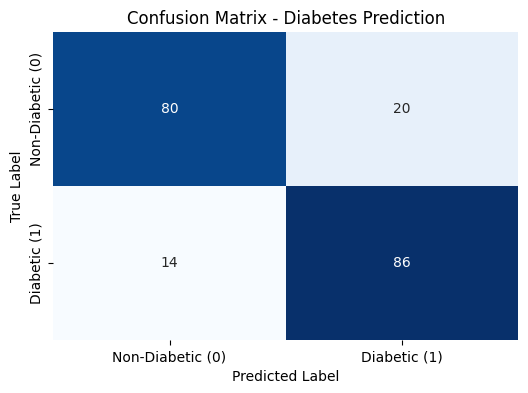

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Diabetic (0)', 'Diabetic (1)'],
            yticklabels=['Non-Diabetic (0)', 'Diabetic (1)'])
plt.title('Confusion Matrix - Diabetes Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
